# Multi-Task Learning on Cifar10 Dataset: A Vision Transformer Approach
- **Name**: Minh T. Nguyen & Peter Chen.
- **ECE 6524** - Final Project.
- **Date**: 4/18/2023.
- **Objective**: Build a Multi-Task model for image classification on Cifar10.

### References:
- Paper: ["An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale"](https://arxiv.org/abs/2010.11929).
- [Author's Github Repository](https://github.com/google-research/vision_transformer).
- [Keras' Image classification with Vision Transformer](https://keras.io/examples/vision/image_classification_with_vision_transformer/)

### Vision Transformers Architecture Explanation
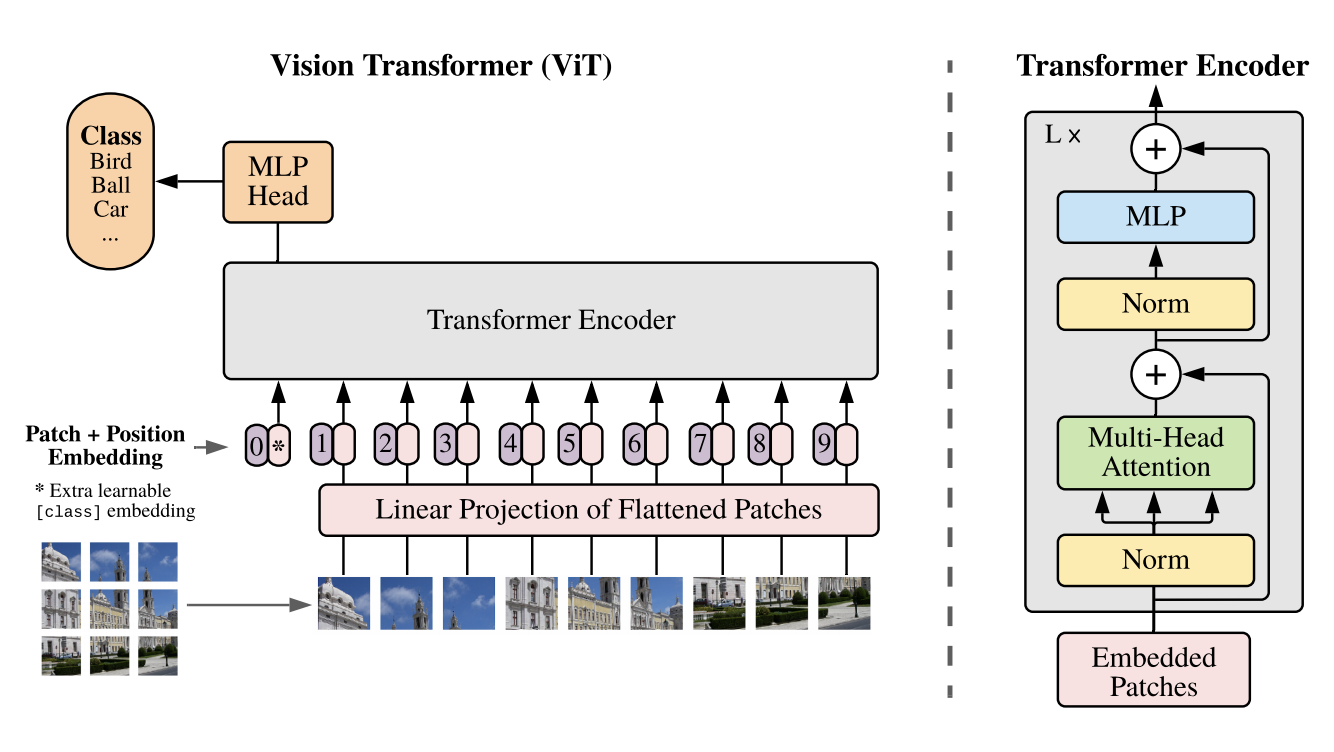

- **About**: Visions tasks were dominated by CNN-based architecture. However, Vision Transformers (ViT) has showed to be a high-capacity network architecture and can outperform CNN-based network on vision Tasks.
- **ViT Architecture**:
    - **Pipeline**: ViT computes the attentions between patches instead of image pixels due to limitation in computational power. **Input > Linear Projection > Stacked Encoder > MLP > Output Labels**
    - **Input Processing**: 
        - Convert Image to Patches.
        - Linear Projection: Each patch is reshaped to 1D vector, then we multiple with a learnable matrix to create a vector (patch linear projection). By doing for all patches, we will get an image linear projection.
        - Position Embedding: ViT is invariant to position on patches. For CNN, convolution is translation and scale equivariant (important for object detection) while pooling is translation and scale invariant (important for image recognition). By combining convolution and pooling, CNN can deal with recognition, object detection, and segmentation. Position embedding allow ViT to behave like CNN. This is the only inductive bias in ViT.  
    - **Transformers Encoder - Self-attention + MLP**:
        - Why do we have Layer Normalization? To reduce training time and stabilizes training phases.
        - Why do we use Skip Connection? To improves the performance by as much as 4% on recognition by propagating representation across layers.
        - Why do we use Multi-Head Self-Attention? To learn different representation of self-attention matrix to boost performance.
    - **MLP + Output**: Prediction outputs.

In [2]:
%pip install numpy matplotlib tensorflow pydot graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 3.8 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 6.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.4/572.4 MB 1.8 MB/s  0:02:42m0:00:0100:09
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 2.1 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 2.9 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 3.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 2.3 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 3.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 3.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 2.6 MB/s  0:00:09m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 3.4 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35/35 [tens

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Import TensorFlow and Keras components safely
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

# FIX: Import 'to_categorical' and 'plot_model' directly, dropping 'np_utils'
from tensorflow.keras.utils import to_categorical, plot_model

# 1. Data Visualization & Preprocessing

In [4]:
# ==============================================================================
# PA-100K DEMOGRAPHIC CONFIGURATION
# ==============================================================================

# Target Columns from CSV: AgeLess18, Age18-60, AgeOver60 (3 mutually exclusive brackets)
num_classes = 3          

# Target Column from CSV: Female (Maps to 2 states: Male [0] or Female [1])
num_super_classes = 2    

# Input Image Size matching UniPAR specifications (Height, Width, Channels)
input_shape = (256, 128, 3) 

# Dataset Absolute System Paths
DATASET_ROOT = "/mnt/datalake/dev/pyaelinn_dev/PA100k_dataset/PA-100K"
IMAGE_DIR    = "/mnt/datalake/dev/pyaelinn_dev/PA100k_dataset/PA-100K/data"

TRAIN_CSV    = "/mnt/datalake/dev/pyaelinn_dev/PA100k_dataset/PA-100K/train.csv"
VALID_CSV    = "/mnt/datalake/dev/pyaelinn_dev/PA100k_dataset/PA-100K/val.csv"
TEST_CSV     = "/mnt/datalake/dev/pyaelinn_dev/PA100k_dataset/PA-100K/test.csv"

# Print configuration summary to verify alignment
print(f"--- Configuration Locked ---")
print(f"Target Age Classes (Fine Head):   {num_classes}")
print(f"Target Gender Classes (Super Head): {num_super_classes}")
print(f"Model Processing Tensor Shape:    {input_shape}")

--- Configuration Locked ---
Target Age Classes (Fine Head):   3
Target Gender Classes (Super Head): 2
Model Processing Tensor Shape:    (256, 128, 3)


In [12]:
%pip install pandas opencv-python tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 515.6 kB/s  0:00:22m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 2.4 MB/s  0:00:33m0:00:0100:02m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]python]
Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
df_check = pd.read_csv("/mnt/datalake/dev/pyaelinn_dev/PA100k_dataset/PA-100K/train.csv", nrows=5)
print("Your actual CSV columns are:")
print(list(df_check.columns))

Your actual CSV columns are:
['Image', 'Female', 'AgeOver60', 'Age18-60', 'AgeLess18', 'Front', 'Side', 'Back', 'Hat', 'Glasses', 'HandBag', 'ShoulderBag', 'Backpack', 'HoldObjectsInFront', 'ShortSleeve', 'LongSleeve', 'UpperStride', 'UpperLogo', 'UpperPlaid', 'UpperSplice', 'LowerStripe', 'LowerPattern', 'LongCoat', 'Trousers', 'Shorts', 'Skirt&Dress', 'boots']


In [5]:
import os
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from tensorflow.keras.utils import to_categorical

def load_single_image_worker(args):
    """Worker thread tasked with parallel image reading and resizing."""
    img_name, image_dir, target_shape = args
    img_path = os.path.join(image_dir, str(img_name))
    
    # Read image from disk
    img = cv2.imread(img_path)
    if img is None:
        return None  # Return None to handle missing files gracefully
        
    # Standardize color space and target resolution matching your 256x128 grid
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (target_shape[1], target_shape[0]))
    return img_resized

def load_demographic_data_fast(csv_path, image_dir, target_shape=(256, 128), max_workers=32):
    print(f"\nParsing annotations from: {os.path.basename(csv_path)}...")
    df = pd.read_csv(csv_path)
    image_column = df.columns[0]
    
    # 1. Isolate and Extract ONLY Your Specified 4 Demographic Attributes
    # Age Columns -> Formulate the 3-node Fine Head categorical matrix
    age_matrix = df[['AgeLess18', 'Age18-60', 'AgeOver60']].values.astype('float32')
    
    # Female Column -> Formulate the 2-node Super Head categorical matrix
    female_raw = df['Female'].values
    gender_matrix = to_categorical(female_raw, num_classes=2)
    
    # 2. Build Multi-Threaded Parallel Processing Tasks
    print(f"Spawning {max_workers} parallel I/O network threads...")
    tasks = [(row[image_column], image_dir, target_shape) for _, row in df.iterrows()]
    
    # Execute the threaded queue across your datalake share
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(tqdm(
            executor.map(load_single_image_worker, tasks), 
            total=len(tasks), 
            desc=f"Streaming {os.path.basename(csv_path)}"
        ))
        
    # 3. Filter out any missing or corrupt file indexes dynamically
    clean_images = []
    valid_indices = []
    for idx, img in enumerate(results):
        if img is not None:
            clean_images.append(img)
            valid_indices.append(idx)
        else:
            print(f"⚠️ Warning: Corrupt/Missing image omitted: {tasks[idx][0]}")
            
    # Convert image list to a continuous block of memory
    X_array = np.array(clean_images, dtype=np.uint8)
    
    # Sync label dimensions to only include successfully loaded frames
    return X_array, age_matrix[valid_indices], gender_matrix[valid_indices]

# ==============================================================================
# EXECUTE HIGH-SPEED DATA PIPELINE
# ==============================================================================
target_h, target_w = input_shape[0], input_shape[1]

# max_workers=32 handles parallel requests to overcome datalake latency bounds
X_train, y_train, y_train_super = load_demographic_data_fast(TRAIN_CSV, IMAGE_DIR, (target_h, target_w), max_workers=32)
X_val, y_val, y_val_super       = load_demographic_data_fast(VALID_CSV, IMAGE_DIR, (target_h, target_w), max_workers=32)
X_test, y_test, y_test_super     = load_demographic_data_fast(TEST_CSV, IMAGE_DIR, (target_h, target_w), max_workers=32)

print("\n🎉 All demographic splits streamed and loaded successfully!")


Parsing annotations from: train.csv...
Spawning 32 parallel I/O network threads...


Streaming train.csv: 100%|██████████| 80000/80000 [03:04<00:00, 432.47it/s]



Parsing annotations from: val.csv...
Spawning 32 parallel I/O network threads...


Streaming val.csv: 100%|██████████| 10000/10000 [00:23<00:00, 434.72it/s]



Parsing annotations from: test.csv...
Spawning 32 parallel I/O network threads...


Streaming test.csv: 100%|██████████| 10000/10000 [00:22<00:00, 440.34it/s]



🎉 All demographic splits streamed and loaded successfully!


## 1.1. Data Visualization

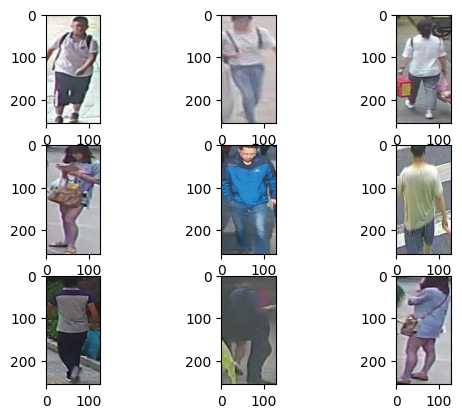

In [8]:
# plot the 9 images
import matplotlib.pyplot as plt

f, axarr = plt.subplots(3,3)
axarr[0,0].imshow(X_train[10])
axarr[0,1].imshow(X_train[11])
axarr[0,2].imshow(X_train[12])
axarr[1,0].imshow(X_train[13])
axarr[1,1].imshow(X_train[14])
axarr[1,2].imshow(X_train[15])
axarr[2,0].imshow(X_train[16])
axarr[2,1].imshow(X_train[17])
axarr[2,2].imshow(X_train[18])
plt.show()

## 1.2. Generate Superclasses
The super-classes are divided into animals and vehicles:
- Animals: Bird, Cat, Deer, Dog, Frog, Horse. (5000x6 training images, 1000x6 testing images).
- Vehicles: Airplane, Automotive, Ship, Truck. (5000x4 training images, 1000x4 testing images).

From Cifar 10 Dataset, we know that the labels have the corresponding label number:
- Airplane: 0.
- Automobile: 1.
- Bird: 2.
- Cat: 3.
- Deer: 4.
- Dog: 5.
- Frog: 6.
- Horse: 7.
- Ship: 8.
- Truck 9.

In [9]:
# ==============================================================================
# DEMOGRAPHIC LABEL ASSIGNMENT (REPLACING CIFAR SUPERCLASS MAPPING)
# ==============================================================================
# No hardcoded mapping needed! Our data loader already extracted:
# y_train / y_test        -> Age One-Hot Matrices (3 classes)
# y_train_super / y_test_super -> Gender One-Hot Matrices (2 classes)

# Print out shape matrices to confirm the setup is correct
print("============================================================")
print("             POST-LOADER VARIABLE VERIFICATION              ")
print("============================================================")
print(f"✅ Training Images (X_train):        {X_train.shape}  (Expected: [N, 256, 128, 3])")
print(f"✅ Training Age Head (y_train):      {y_train.shape}  (Expected: [N, 3])")
print(f"✅ Training Gender Head (y_train_s): {y_train_super.shape}  (Expected: [N, 2])")
print("------------------------------------------------------------")
print(f"✅ Testing Images (X_test):          {X_test.shape}  (Expected: [N, 256, 128, 3])")
print(f"✅ Testing Age Head (y_test):        {y_test.shape}  (Expected: [N, 3])")
print(f"✅ Testing Gender Head (y_test_s):   {y_test_super.shape}  (Expected: [N, 2])")
print("============================================================")

             POST-LOADER VARIABLE VERIFICATION              
✅ Training Images (X_train):        (80000, 256, 128, 3)  (Expected: [N, 256, 128, 3])
✅ Training Age Head (y_train):      (80000, 3)  (Expected: [N, 3])
✅ Training Gender Head (y_train_s): (80000, 2)  (Expected: [N, 2])
------------------------------------------------------------
✅ Testing Images (X_test):          (10000, 256, 128, 3)  (Expected: [N, 256, 128, 3])
✅ Testing Age Head (y_test):        (10000, 3)  (Expected: [N, 3])
✅ Testing Gender Head (y_test_s):   (10000, 2)  (Expected: [N, 2])


## 1.3. Data Processing

In [10]:
# ==============================================================================
# ONE-HOT ENCODING CHECK (SKIPPING CONVERSION AS IT IS ALREADY PRE-ENCODED)
# ==============================================================================
# Our custom PA-100K data loader already structured these variables into 
# high-performance categorical matrices. We only need to verify their shapes:

print('============================================================')
print('                 FINAL LABEL SHAPE CHECK                    ')
print('============================================================')
print('🎯 Fine Head Target - y_train (Age) shape:       ', y_train.shape)
print('🎯 Fine Head Target - y_test (Age) shape:        ', y_test.shape)
print('------------------------------------------------------------')
print('🎯 Super Head Target - y_train_super (Gender) shape:', y_train_super.shape)
print('🎯 Super Head Target - y_test_super (Gender) shape: ', y_test_super.shape)
print('============================================================')

                 FINAL LABEL SHAPE CHECK                    
🎯 Fine Head Target - y_train (Age) shape:        (80000, 3)
🎯 Fine Head Target - y_test (Age) shape:         (10000, 3)
------------------------------------------------------------
🎯 Super Head Target - y_train_super (Gender) shape: (80000, 2)
🎯 Super Head Target - y_test_super (Gender) shape:  (10000, 2)


## 1.2. Data Augmentation

In [13]:
# ==============================================================================
# VISION TRANSFORMER RECTANGULAR PATCH CONFIGURATION
# ==============================================================================

# Match your PA-100K input_shape dimensions exactly
image_height = input_shape[0]  # 256
image_width  = input_shape[1]  # 128

# Standard ViT patch dimensions (16x16 pixels per patch)
patch_size = 16  

# Calculate patches across a rectangular grid
num_patches = (image_height // patch_size) * (image_width // patch_size)

print("============================================================")
print("             VIT PATCH SYSTEM RECONFIGURED                  ")
print("============================================================")
print(f"📐 Target Resolution: {image_width}x{image_height} (Width x Height)")
print(f"🧩 Patch Dimensions:  {patch_size}x{patch_size} Pixels")
print(f"📊 Total Patches:     {num_patches} patches per pedestrian crop")
print("============================================================")

# Create a specialized preprocessing pipeline
data_aug = keras.Sequential(
    [
        layers.Normalization(),                   # Scales and centers pixel values
        layers.Resizing(image_height, image_width), # Locks in your strict 2:1 vertical ratio
    ],
    name="data_augmentation",
)

# ==============================================================================
# HIGH-SPEED MEMORY-SAFE NORMALIZATION ADAPTATION
# ==============================================================================
print("\n🔄 Selecting a representative sample to prevent memory freeze...")
sample_size = min(5000, len(X_train))

# Generates a random, shuffled selection of image indices
np.random.seed(42) # Ensures reproducibility
random_indices = np.random.choice(len(X_train), size=sample_size, replace=False)
X_train_sample = X_train[random_indices]

print(f"🚀 Adapting normalization layer using {sample_size} sample frames...")

# If a GPU is present, TensorFlow will automatically leverage it for this calculation
with tf.device('/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'):
    data_aug.layers[0].adapt(X_train_sample)

print("💪 Normalization matrix calculation complete in seconds!")

# Clean up memory immediately
del X_train_sample

             VIT PATCH SYSTEM RECONFIGURED                  
📐 Target Resolution: 128x256 (Width x Height)
🧩 Patch Dimensions:  16x16 Pixels
📊 Total Patches:     128 patches per pedestrian crop

🔄 Selecting a representative sample to prevent memory freeze...
🚀 Adapting normalization layer using 5000 sample frames...


W0000 00:00:1779682421.574400  929341 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1779682421.839932  898894 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


💪 Normalization matrix calculation complete in seconds!


In [14]:
print(f"The total number of patches in an splitted image is {num_patches}.")

The total number of patches in an splitted image is 128.


## 1.3. Patch Transformation
**Note**: Convert an input image into a patch-dimension. The class Patch's job is to transform image to patch-dimension. For instance, with our input image as **(1, 72, 72, 3)** = (1 image, 72 width pixel, 72 height pixel, 3 color channel), the output will be **(1, 12, 12, 108)** = (1 image, 12 width patch, 12 height patch, 108 depth).

In [15]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        """Constructor"""
        super().__init__()
        self.patch_size = patch_size
        
    def call(self, images):
        """Forward-pass function"""
        batch_size = tf.shape(images)[0]
        
        # pixel to patch conversion
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1,1,1,1],
            padding="VALID",
        )
        
        # get depth
        patch_dims = patches.shape[-1]
        
        # resize
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

**Note**: Let's go through an example

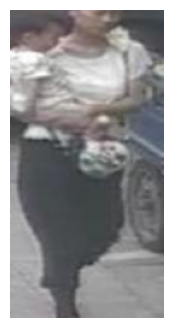

In [16]:
# plot original image
plt.figure(figsize=(4,4))
image = X_train[0]
plt.imshow(image.astype("uint8"))
plt.axis("off")
plt.show()

             PATCH VISUALIZATION GRID GENERATED             
📊 Rendering a structural grid of: 16 Rows x 8 Columns
🎯 Total target subplots needed:  128


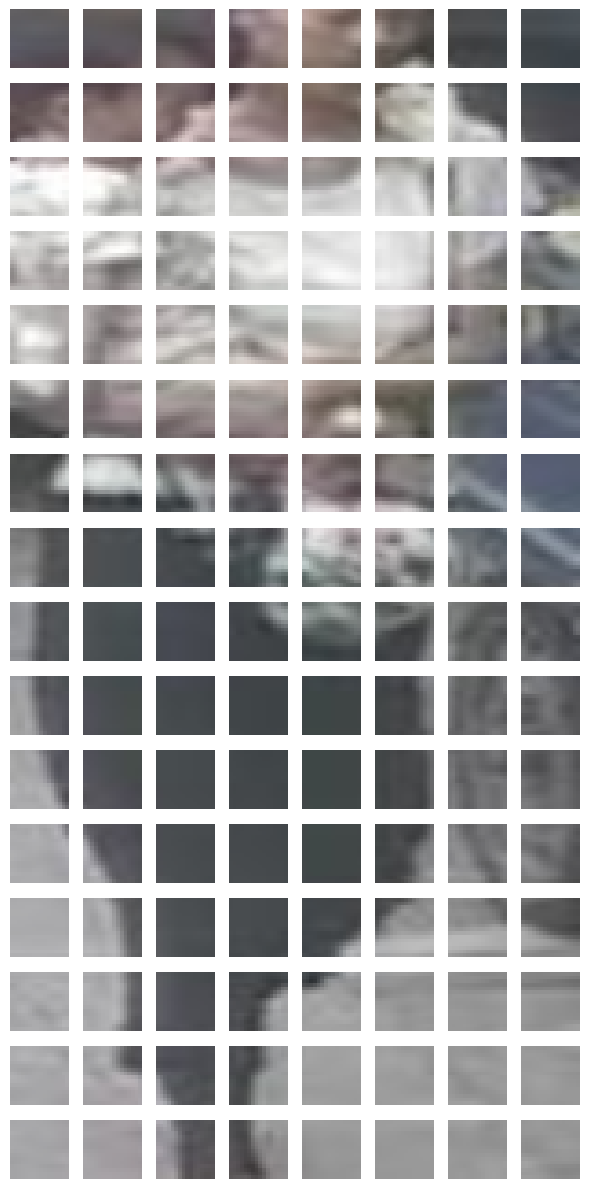

In [17]:
# ==============================================================================
# RECTANGULAR PATCH VISUALIZATION PIPELINE
# ==============================================================================

# Select the first pedestrian crop from your loaded dataset array
image = X_train[0]

# Resize using your strict vertical 256x128 dimensions
resized_image = tf.image.resize(
    tf.convert_to_tensor([image]), size=(image_height, image_width)
)

# Generate patches via the dynamic Patches layer
patches = Patches(patch_size)(resized_image)

# FIX: Explicitly calculate the distinct row and column counts
n_rows = image_height // patch_size  # 256 // 16 = 16 vertical blocks
n_cols = image_width // patch_size   # 128 // 16 = 8 horizontal blocks

print("============================================================")
print("             PATCH VISUALIZATION GRID GENERATED             ")
print("============================================================")
print(f"📊 Rendering a structural grid of: {n_rows} Rows x {n_cols} Columns")
print(f"🎯 Total target subplots needed:  {patches.shape[1]}")
print("============================================================")

# Adjust figure size to match your tall 2:1 vertical layout aspect ratio
plt.figure(figsize=(6, 12))

# Loop through all 128 patches safely
for i, patch in enumerate(patches[0]):
    # Dynamically place each patch onto the 16x8 layout grid
    ax = plt.subplot(n_rows, n_cols, i + 1)
    
    # Reassemble the patch vector back into a viewable 16x16 RGB image block
    patch_img = tf.reshape(patch, (patch_size, patch_size, 3))
    
    plt.imshow(patch_img.numpy().astype("uint8"))
    plt.axis("off")

plt.tight_layout()
plt.show()

**Note**: Let's get some calculated patches results after the transformation

In [19]:
print(f"Original image size: {image} x {image}.")
print(f"Calculated patch size: {patch_size} x {patch_size}.")
print(f"Number of patches per image: {patches.shape[1]}.")
print(f"Depth size of each patch: {patches.shape[-1]}.")

Original image size: [[[ 98  96  99]
  [ 98  96  99]
  [ 97  95  98]
  ...
  [ 74  81  87]
  [ 75  82  88]
  [ 75  82  88]]

 [[ 97  95  98]
  [ 96  94  97]
  [ 96  94  97]
  ...
  [ 73  80  86]
  [ 73  80  86]
  [ 73  81  87]]

 [[ 95  93  97]
  [ 95  93  97]
  [ 95  93  97]
  ...
  [ 72  79  85]
  [ 73  80  86]
  [ 73  80  86]]

 ...

 [[164 164 166]
  [164 164 166]
  [165 165 167]
  ...
  [135 135 135]
  [135 135 135]
  [135 135 135]]

 [[164 164 166]
  [164 164 166]
  [165 165 167]
  ...
  [135 135 135]
  [136 136 136]
  [137 137 137]]

 [[164 164 166]
  [164 164 166]
  [165 165 167]
  ...
  [138 138 138]
  [139 139 139]
  [140 140 140]]] x [[[ 98  96  99]
  [ 98  96  99]
  [ 97  95  98]
  ...
  [ 74  81  87]
  [ 75  82  88]
  [ 75  82  88]]

 [[ 97  95  98]
  [ 96  94  97]
  [ 96  94  97]
  ...
  [ 73  80  86]
  [ 73  80  86]
  [ 73  81  87]]

 [[ 95  93  97]
  [ 95  93  97]
  [ 95  93  97]
  ...
  [ 72  79  85]
  [ 73  80  86]
  [ 73  80  86]]

 ...

 [[164 164 166]
  [164 164 16

# 2. Modeling
**Note**: Build a Patch Encoding Layer and Build a Vision Transformers architecture.

In [20]:
# the size of the project dimension is just how depth the PatchEncoder layer prior to fetch to the Transformers
projection_dim = 64 

## 2.1. Patch Encoding Layer
**Note**: We will fetch each patch through a "Linear Projection of Flatten Patches" (aka, transform dimension via Dense layer) and attached the learnable Positional Embedding layer.

**Note**: Let's first visualize the positional embedding matrix. Each number is the position of each patch.

In [21]:
# FIX: Replace the hardcoded 144 with your dynamic 'num_patches' variable (128)
print("============================================================")
print("               TRANSFORMER INPUT POSITIONAL SEQUENCE        ")
print("============================================================")
print(f"Target position indices being mapped for your ViT layers (0 to {num_patches - 1}):")
print(tf.range(start=0, limit=num_patches, delta=1))
print("============================================================")

               TRANSFORMER INPUT POSITIONAL SEQUENCE        
Target position indices being mapped for your ViT layers (0 to 127):
tf.Tensor(
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127], shape=(128,), dtype=int32)


In [23]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        """Constructor"""
        super().__init__()
        self.num_patches = num_patches                       # (12 x 12) = 144 patches
        self.projection = layers.Dense(units=projection_dim) # Dense layer that map the patched input to the projection_dim
        self.position_embedding = layers.Embedding(          # learnable embedding layer for the position (above)
            input_dim = num_patches, output_dim = projection_dim
        )
        
    def call(self, patch):
        """Forward Pass"""
        # create a position matrix
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        
        # resize the input patch with Dense
        input_patch = self.projection(patch)
        
        # encode position array with learnable embedding layer
        pos_emb = self.position_embedding(positions)
        
        # patch + position embedding
        encoded_patch = input_patch + pos_emb
        
        return encoded_patch

## 2.2. Vision Transformers
**Note**: Input > Linear Projection > Stacked Encoder > MLP > Output Labels

In [24]:
# training settings
batch_size = 256          # number of images per batch
num_heads = 4             # nummber of attention heads in the multi-attention layer
num_epochs = 20           # number of training epochs
transformer_dropout = 0.2 # dropout rate of mlp inner of transformers
mlp_dropout = 0.2         # dropout rate of mlp outside of transformers

# transformers settings
transformer_layers = 8    # number of stacked encoder layers

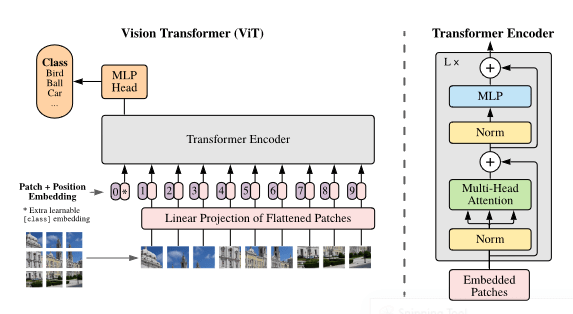

In [25]:
def create_model(mlp_dropout):
    # Set input layer matching your (256, 128, 3) specification
    inputs = layers.Input(shape=input_shape, name="input")

    # Normalize and resize image
    augmented = data_aug(inputs)

    # Convert image's pixels into patches
    patches = Patches(patch_size)(augmented)

    # Encode patch by linearly transforming patch with dense and adding the learnable position encoder
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Create stacked encoder blocks
    for _ in range(transformer_layers):
        # Layer normalization 1
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)

        # Multi-head attention
        mtha = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)

        # Skip connection 1 = add input with mtha
        x2 = layers.Add()([mtha, encoded_patches])

        # Layer normalization 2
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

        # MLP
        x4 = layers.Dense(projection_dim * 2, activation=tf.nn.gelu)(x3)
        x4 = layers.Dropout(transformer_dropout)(x4)
        x4 = layers.Dense(projection_dim, activation=tf.nn.gelu)(x4)
        x4 = layers.Dropout(transformer_dropout)(x4)

        # Skip connection 2
        encoded_patches = layers.Add()([x4, x2])

    # Flatten transformer outputs for final classification features
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(mlp_dropout)(representation)
    features = layers.Dense(2048, activation=tf.nn.gelu)(representation)
    features = layers.Dropout(mlp_dropout)(features)
    
    # ==========================================================================
    # AGE CLASSIFICATION HEAD (Replacing Task 1)
    # ==========================================================================
    age_branch = layers.Dense(1024, activation=tf.nn.gelu)(features)
    age_branch = layers.Dropout(mlp_dropout)(age_branch)
    age_branch = layers.Dense(512, activation=tf.nn.gelu)(age_branch)
    age_branch = layers.Dropout(mlp_dropout)(age_branch)
    age_branch = layers.Dense(256, activation=tf.nn.gelu)(age_branch)
    age_branch = layers.Dropout(mlp_dropout)(age_branch)
    age_branch = layers.Dense(128, activation=tf.nn.gelu)(age_branch)
    age_branch = layers.Dropout(mlp_dropout)(age_branch)
    age_output = layers.Dense(num_classes, activation="softmax", name="age_output")(age_branch)
    
    # ==========================================================================
    # GENDER CLASSIFICATION HEAD (Replacing Task 2)
    # ==========================================================================
    gender_branch = layers.Dense(512, activation=tf.nn.gelu)(features)
    gender_branch = layers.Dropout(mlp_dropout)(gender_branch)
    gender_branch = layers.Dense(256, activation=tf.nn.gelu)(gender_branch)
    gender_branch = layers.Dropout(mlp_dropout)(gender_branch)
    gender_branch = layers.Dense(128, activation=tf.nn.gelu)(gender_branch)
    gender_branch = layers.Dropout(mlp_dropout)(gender_branch)
    gender_output = layers.Dense(num_super_classes, activation="softmax", name="gender_output")(gender_branch)
        
    # Create multi-task output graph configuration
    model = keras.Model(inputs=inputs, outputs=[age_output, gender_output])
    
    return model

In [26]:
# create a model
model = create_model(mlp_dropout=mlp_dropout)

In [27]:
# print model summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 256, 128,  │          7 │ input[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_1 (Patches) │ (None, None, 768) │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 128, 64)   │     57,408 │ patches_1[0][0]   │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128, 64)   │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128, 64)   │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128, 64)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 64)   │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 128, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128, 128)  │          0 │ dense_3[0][0]   

 Total params: 21,503,564 (82.03 MB)

 Trainable params: 21,503,557 (82.03 MB)

 Non-trainable params: 7 (32.00 B)

In [28]:
# plot architectures
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


## 2.3. Compile Model

In [29]:
# ==============================================================================
# MULTI-TASK LOSS AND COMPILATION CONFIGURATION
# ==============================================================================

# Gamma balances the impact of each task on the shared backbone weights.
# At 0.5, the total loss is split exactly 50/50 between Age and Gender.
gamma = 0.5

# Compile the model targeting your explicit demographic heads
model.compile(
    loss={
        'age_output': 'categorical_crossentropy',
        'gender_output': 'categorical_crossentropy' # Updated to match your 2-node softmax setup
    },
    loss_weights={
        'age_output': gamma,
        'gender_output': 1.0 - gamma
    },
    optimizer='adam',
    metrics=['accuracy']
)

print("============================================================")
print("             MODEL COMPILATION SUCCESSFUL                   ")
print("============================================================")
print(f"🎯 Age Head Loss:     categorical_crossentropy (Weight: {gamma})")
print(f"🎯 Gender Head Loss:  categorical_crossentropy (Weight: {1.0 - gamma})")
print(f"⚙️  Optimizer:         Adam")
print("============================================================")

             MODEL COMPILATION SUCCESSFUL                   
🎯 Age Head Loss:     categorical_crossentropy (Weight: 0.5)
🎯 Gender Head Loss:  categorical_crossentropy (Weight: 0.5)
⚙️  Optimizer:         Adam


## 2.4. Train & Validate Model

In [30]:
# ==============================================================================
# LOCAL-SAFE TRAINING CALLBACKS CONFIGURATION
# ==============================================================================

# Create a clean, relative path that saves directly into your current working directory
checkpoint_path = "./best_multitask_vit_model.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,    # Only overwrites if total val_loss improves
        monitor="val_loss",     # Tracks combined weighted age + gender validation loss
        mode="min",             # We want to minimize the loss scalar
        verbose=1               # Prints a notification whenever a better model is saved
    )
]

print("============================================================")
print("             CALLBACKS TRACKING SYSTEM ACTIVE               ")
print("============================================================")
print(f"💾 Target Checkpoint Path: {os.path.abspath(checkpoint_path)}")
print(f"📊 Performance Metric:     val_loss (Combined Multi-Task Target)")
print("============================================================")

             CALLBACKS TRACKING SYSTEM ACTIVE               
💾 Target Checkpoint Path: /home/gwmm-server3/Projects/PyaeLinn/multitask_learning_vit/best_multitask_vit_model.keras
📊 Performance Metric:     val_loss (Combined Multi-Task Target)


In [33]:
print("⚙️ Compiling model with explicit structural lists...")
# 2. Compile using LISTS to match outputs=[age_output, gender_output] exactly.
# This prevents Keras 3 dictionary string-matching bugs.
gamma = 0.5
model.compile(
    optimizer='adam',
    loss=[
        'categorical_crossentropy',  # Maps directly to age_output (Index 0)
        'categorical_crossentropy'   # Maps directly to gender_output (Index 1)
    ],
    loss_weights=[
        gamma,                       # Age loss weight
        1.0 - gamma                  # Gender loss weight
    ],
    metrics=[
        ['accuracy'],                # Tracking metric for age_output
        ['accuracy']                 # Tracking metric for gender_output
    ]
)

print("🚀 Igniting Multi-Task Vision Transformer Training Loop...")
# 3. Fit the model using list-matching targets
history = model.fit(
    X_train,                                      # Input image tensor
    [y_train, y_train_super],                     # Targets passed as an ordered list
    batch_size=batch_size,
    epochs=num_epochs,
    validation_data=(
        X_val,                                    # Validation image tensor
        [y_val, y_val_super]                      # Validation targets list
    ),
    callbacks=callbacks,
    verbose=1
)

⚙️ Compiling model with explicit structural lists...
🚀 Igniting Multi-Task Vision Transformer Training Loop...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - age_output_accuracy: 0.9305 - age_output_loss: 0.2804 - gender_output_accuracy: 0.6435 - gender_output_loss: 0.6924 - loss: 0.4864
Epoch 1: val_loss improved from None to 0.52387, saving model to ./best_multitask_vit_model.keras

Epoch 1: finished saving model to ./best_multitask_vit_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 587s 2s/step - age_output_accuracy: 0.9498 - age_output_loss: 0.2038 - gender_output_accuracy: 0.7023 - gender_output_loss: 0.5758 - loss: 0.3899 - val_age_output_accuracy: 0.8615 - val_age_output_loss: 0.4609 - val_gender_output_accuracy: 0.7027 - val_gender_output_loss: 0.5772 - val_loss: 0.5239
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - age_output_accuracy: 0.9649 - age_output_loss: 0.1288 - gender_output_accuracy: 0.7884 - gender_output_loss: 0.4472 - loss: 0.2880
Epoch 2: val_loss did not i

In [34]:
# ==============================================================================
# PRINT FINAL MULTI-TASK TRAINING AND VALIDATION METRICS
# ==============================================================================

# 💡 Dynamic key detection to remain 100% immune to Keras 3 naming variants
keys = history.history.keys()
age_loss_k = 'age_output_loss' if 'age_output_loss' in keys else 'output_0_loss'
age_acc_k  = 'age_output_accuracy' if 'age_output_accuracy' in keys else 'output_0_accuracy'

gen_loss_k = 'gender_output_loss' if 'gender_output_loss' in keys else 'output_1_loss'
gen_acc_k  = 'gender_output_accuracy' if 'gender_output_accuracy' in keys else 'output_1_accuracy'

print("=======================================================================")
print("                  VIT DEMOGRAPHIC TRAINING SUMMARY                     ")
print("=======================================================================")
print(f"📊 COMBINED TOTALS:")
print(f"   - Total Combined Train Loss:     {history.history['loss'][-1]:.4f}")
print(f"   - Total Combined Valid Loss:     {history.history['val_loss'][-1]:.4f}\n")

print(f"🎯 AGE HEAD RESULTS (3-Class Fine Target):")
print(f"   - Train Loss:                    {history.history[age_loss_k][-1]:.4f}")
print(f"   - Validation Loss:               {history.history['val_' + age_loss_k][-1]:.4f}")
print(f"   - Train Accuracy:                {history.history[age_acc_k][-1] * 100:.2f}%")
print(f"   - Validation Accuracy:           {history.history['val_' + age_acc_k][-1] * 100:.2f}%\n")

print(f"🎯 GENDER HEAD RESULTS (2-Class Super Target):")
print(f"   - Train Loss:                    {history.history[gen_loss_k][-1]:.4f}")
print(f"   - Validation Loss:               {history.history['val_' + gen_loss_k][-1]:.4f}")
print(f"   - Train Accuracy:                {history.history[gen_acc_k][-1] * 100:.2f}%")
print(f"   - Validation Accuracy:           {history.history['val_' + gen_acc_k][-1] * 100:.2f}%")
print("=======================================================================")

                  VIT DEMOGRAPHIC TRAINING SUMMARY                     
📊 COMBINED TOTALS:
   - Total Combined Train Loss:     0.0183
   - Total Combined Valid Loss:     1.4619

🎯 AGE HEAD RESULTS (3-Class Fine Target):
   - Train Loss:                    0.0077
   - Validation Loss:               1.6271
   - Train Accuracy:                99.82%
   - Validation Accuracy:           85.42%

🎯 GENDER HEAD RESULTS (2-Class Super Target):
   - Train Loss:                    0.0290
   - Validation Loss:               1.2693
   - Train Accuracy:                99.02%
   - Validation Accuracy:           72.45%


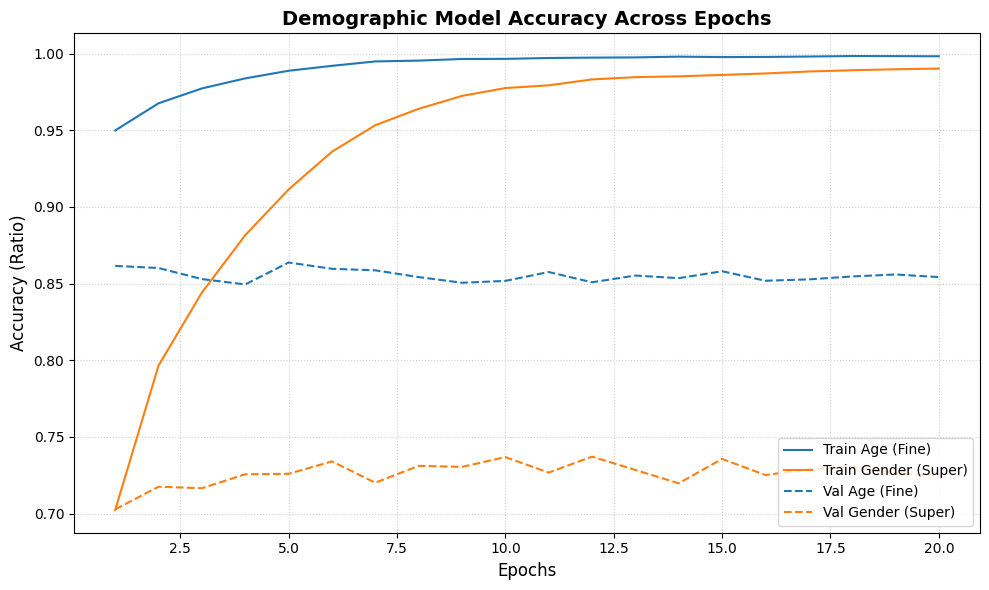

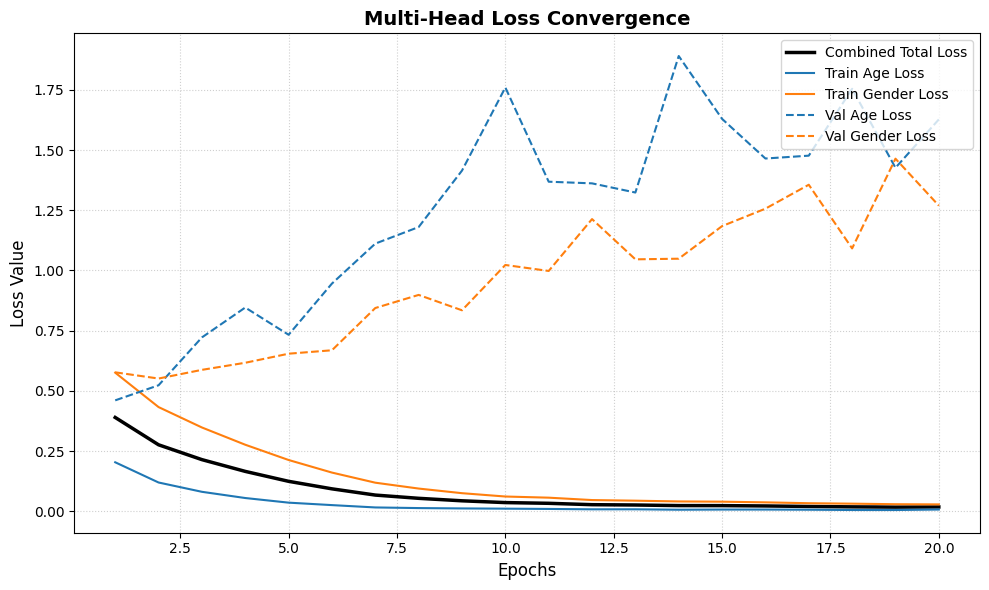

In [35]:
import matplotlib.pyplot as plt

# ==============================================================================
# MULTI-TASK ACCURACY AND LOSS VISUALIZATION
# ==============================================================================

# 💡 Dynamic key detection to remain 100% immune to Keras 3 naming variants
keys = history.history.keys()
age_loss_k = 'age_output_loss' if 'age_output_loss' in keys else 'output_0_loss'
age_acc_k  = 'age_output_accuracy' if 'age_output_accuracy' in keys else 'output_0_accuracy'

gen_loss_k = 'gender_output_loss' if 'gender_output_loss' in keys else 'output_1_loss'
gen_acc_k  = 'gender_output_accuracy' if 'gender_output_accuracy' in keys else 'output_1_accuracy'

# Establish X-axis range based on actual completed epochs
epochs_range = range(1, len(history.history['loss']) + 1)

# --------------------------------------------------------------------------
# CHART 1: MODEL ACCURACY PERFORMACT TRAILING
# --------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(epochs_range, history.history[age_acc_k], label='Train Age (Fine)', linestyle='-', color='tab:blue')
plt.plot(epochs_range, history.history[gen_acc_k], label='Train Gender (Super)', linestyle='-', color='tab:orange')
plt.plot(epochs_range, history.history['val_' + age_acc_k], label='Val Age (Fine)', linestyle='--', color='tab:blue')
plt.plot(epochs_range, history.history['val_' + gen_acc_k], label='Val Gender (Super)', linestyle='--', color='tab:orange')

plt.title('Demographic Model Accuracy Across Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (Ratio)', fontsize=12)
plt.xlabel('Epochs', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------
# CHART 2: MULTI-HEAD LOSS CONVERGENCE TRAILING
# --------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(epochs_range, history.history['loss'], label='Combined Total Loss', linewidth=2.5, color='black')
plt.plot(epochs_range, history.history[age_loss_k], label='Train Age Loss', linestyle='-', color='tab:blue')
plt.plot(epochs_range, history.history[gen_loss_k], label='Train Gender Loss', linestyle='-', color='tab:orange')
plt.plot(epochs_range, history.history['val_' + age_loss_k], label='Val Age Loss', linestyle='--', color='tab:blue')
plt.plot(epochs_range, history.history['val_' + gen_loss_k], label='Val Gender Loss', linestyle='--', color='tab:orange')

plt.title('Multi-Head Loss Convergence', fontsize=14, fontweight='bold')
plt.ylabel('Loss Value', fontsize=12)
plt.xlabel('Epochs', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 2.5. Test Trained Model

In [ ]:
# ==============================================================================
# FINAL TEST DATASET BENCHMARK EVALUATION
# ==============================================================================

print("🧪 Running evaluation on the unseen PA-100K Test Split...")
evaluation_results = model.evaluate(
    X_test, 
    [y_test, y_test_super],
    batch_size=batch_size,
    verbose=0
)

# Zip metrics names together with their evaluation numbers to form a dynamic lookup dictionary
metrics_dict = dict(zip(model.metrics_names, evaluation_results))

# Dynamic fallbacks to protect against Keras 3 naming variants (layer names vs output indices)
age_loss_val = metrics_dict.get('age_output_loss', metrics_dict.get('output_0_loss', evaluation_results[1]))
age_acc_val  = metrics_dict.get('age_output_accuracy', metrics_dict.get('output_0_accuracy', evaluation_results[3]))

gen_loss_val = metrics_dict.get('gender_output_loss', metrics_dict.get('output_1_loss', evaluation_results[2]))
gen_acc_val  = metrics_dict.get('gender_output_accuracy', metrics_dict.get('output_1_accuracy', evaluation_results[4]))

print("=======================================================================")
print("                  FINAL TEST BENCHMARK PERFORMANCE                     ")
print("=======================================================================")
print(f"📊 COMBINED TOTALS:")
print(f"   - Final Test Combined Loss:       {metrics_dict.get('loss', evaluation_results[0]):.4f}\n")

print(f"🎯 AGE HEAD PERFORMANCE (3-Class Fine Target):")
print(f"   - Test Loss:                     {age_loss_val:.4f}")
print(f"   - Test Accuracy:                 {age_acc_val * 100:.2f}%\n")

print(f"🎯 GENDER HEAD PERFORMANCE (2-Class Super Target):")
print(f"   - Test Loss:                     {gen_loss_val:.4f}")
print(f"   - Test Accuracy:                 {gen_acc_val * 100:.2f}%")
print("=======================================================================")

In [41]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras

# ==============================================================================
# CONFIGURATION AND TARGET PATHS
# ==============================================================================
MODEL_PATH = "/home/gwmm-server3/Projects/PyaeLinn/multitask_learning_vit/best_multitask_vit_model.keras"

# 💡 CHANGE THIS string to point to whichever image file you want to test!
IMAGE_PATH = "/mnt/datalake/dev/pyaelinn_dev/PA100k_dataset/PA-100K/data/000001.jpg"

# Human-readable labels mapped exactly to your dataset's column arrays
AGE_CLASSES = ["Less than 18 years old (Child/Teen)", "18 to 60 years old (Adult)", "Over 60 years old (Senior)"]
GENDER_CLASSES = ["Male", "Female"]

# ==============================================================================
# 1. LOAD TRAINED MODEL WITH CUSTOM OBJECTS REGISTERED
# ==============================================================================
print("🔄 Loading multi-task Vision Transformer model...")
try:
    model = keras.models.load_model(
        MODEL_PATH,
        custom_objects={
            "Patches": Patches,
            "PatchEncoder": PatchEncoder
        }
    )
    print("✅ Model successfully loaded into memory layout!")
except Exception as e:
    print(f"❌ Error loading model: {e}\n(Make sure the 'Patches' and 'PatchEncoder' classes are run in your notebook before this cell.)")

# ==============================================================================
# 2. IMAGE PREPROCESSING PIPELINE
# ==============================================================================
def preprocess_inference_image(img_path, target_shape=(256, 128)):
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Target image path does not exist: {img_path}")
        
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"OpenCV failed to read/decode image data: {img_path}")
        
    # Standardize colors and scale dimensions to your structural 2:1 rectangular specification
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (target_shape[1], target_shape[0]))
    
    # Expand dimensions from (256, 128, 3) to batch format (1, 256, 128, 3)
    return np.expand_dims(img_resized, axis=0)

# ==============================================================================
# 3. RUN MULTI-TASK INFERENCE
# ==============================================================================
try:
    # Prepare tensor
    input_tensor = preprocess_inference_image(IMAGE_PATH, target_shape=(256, 128))
    
    print(f"🔮 Computing attention maps and running predictions on: {os.path.basename(IMAGE_PATH)}...")
    predictions = model.predict(input_tensor, verbose=0)
    
    # Extract prediction array probability vectors (Index 0 = Age, Index 1 = Gender)
    age_probabilities = predictions[0][0]
    gender_probabilities = predictions[1][0]
    
    # Identify index of highest probability score
    predicted_age_idx = np.argmax(age_probabilities)
    predicted_gender_idx = np.argmax(gender_probabilities)
    
    # ==========================================================================
    # PRINT RESULTS REPORT
    # ==========================================================================
    print("\n=======================================================================")
    print("                  PA-100K MULTI-TASK PREDICTION REPORT                 ")
    print("=======================================================================")
    print(f"📷 File Analyzed:     {os.path.basename(IMAGE_PATH)}")
    print("-----------------------------------------------------------------------")
    print(f"👴 Estimated Age:     {AGE_CLASSES[predicted_age_idx]}")
    print(f"   Confidence Score:  {age_probabilities[predicted_age_idx] * 100:.2f}%")
    print("-----------------------------------------------------------------------")
    print(f"🚹 Predicted Gender:  {GENDER_CLASSES[predicted_gender_idx]}")
    print(f"   Confidence Score:  {gender_probabilities[predicted_gender_idx] * 100:.2f}%")
    print("=======================================================================")

except Exception as e:
    print(f"❌ Inference Session Aborted: {e}")

🔄 Loading multi-task Vision Transformer model...
❌ Error loading model: <class 'keras.src.models.functional.Functional'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {}, 'registered_name': 'Functional', 'build_config': {'input_shape': None}, 'compile_config': {'optimizer': {'module': 'keras.optimizers', 'class_name': 'Adam', 'config': {'name': 'adam', 'learning_rate': 0.0010000000474974513, 'weight_decay': None, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}, 'registered_name': None}, 'loss': ['categorical_crossentr

In [42]:
import tensorflow as tf
from tensorflow.keras import layers

# ==============================================================================
# KERAS 3 SERIALIZATION-COMPATIBLE VIT CUSTOM LAYERS
# ==============================================================================

class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        # Pass background properties (trainable, dtype, name) directly to super
        super().__init__(**kwargs)
        self.patch_size = patch_size
        
    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

    def get_config(self):
        # Allows Keras to serialize this layer configuration properly
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config


class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )
        
    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        input_patch = self.projection(patch)
        pos_emb = self.position_embedding(positions)
        return input_patch + pos_emb

    def get_config(self):
        # Allows Keras to serialize this layer configuration properly
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim
        })
        return config

print("✅ Custom layers upgraded with serialization capabilities!")

✅ Custom layers upgraded with serialization capabilities!


🔍 Searching database logs for image metadata...
🔄 Loading multi-task Vision Transformer model...


/home/gwmm-server3/miniconda3/envs/tensor/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'patch_encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/tmp/ipykernel_898894/3095842232.py:120: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_898894/3095842232.py:120: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_898894/3095842232.py:120: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gwmm-server3/miniconda3/envs/tensor/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyp

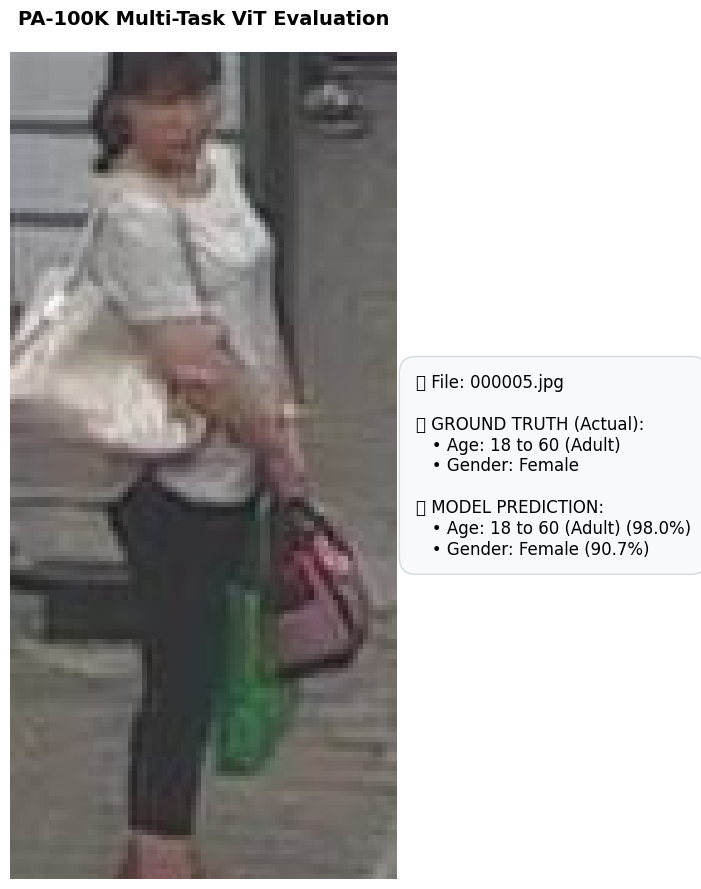

In [44]:
import os
import cv2
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# ==============================================================================
# CONFIGURATION AND TARGET PATHS
# ==============================================================================
MODEL_PATH = "/home/gwmm-server3/Projects/PyaeLinn/multitask_learning_vit/best_multitask_vit_model.keras"

# 💡 CHANGE THIS string to test any specific image from your dataset directory
IMAGE_PATH = "/mnt/datalake/dev/pyaelinn_dev/PA100k_dataset/PA-100K/data/000005.jpg"

# Human-readable labels mapped exactly to your dataset arrays
AGE_CLASSES = ["Less than 18 (Child/Teen)", "18 to 60 (Adult)", "Over 60 (Senior)"]
GENDER_CLASSES = ["Male", "Female"]

# ==============================================================================
# 1. DYNAMIC GROUND TRUTH (GT) CSV LOOKUP
# ==============================================================================
def lookup_ground_truth(img_path):
    filename = os.path.basename(img_path)
    gt_age = "Unknown (Not found in CSV logs)"
    gt_gender = "Unknown (Not found in CSV logs)"
    
    # Use the path variables defined earlier in your notebook configuration
    csv_splits = [TEST_CSV, VALID_CSV, TRAIN_CSV]
    
    for csv_path in csv_splits:
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            # Match the image name against the first column of the CSV
            match = df[df[df.columns[0]] == filename]
            
            if not match.empty:
                row = match.iloc[0]
                # Extract Gender GT
                gt_gender = "Female" if row['Female'] == 1 else "Male"
                
                # Extract Age GT
                if row['AgeLess18'] == 1:
                    gt_age = AGE_CLASSES[0]
                elif row['Age18-60'] == 1:
                    gt_age = AGE_CLASSES[1]
                elif row['AgeOver60'] == 1:
                    gt_age = AGE_CLASSES[2]
                break 
                
    return gt_age, gt_gender

# Fetch ground truth parameters before running prediction
print("🔍 Searching database logs for image metadata...")
gt_age, gt_gender = lookup_ground_truth(IMAGE_PATH)

# ==============================================================================
# 2. LOAD TRAINED MODEL WITH RECONFIGURED CUSTOM OBJECTS
# ==============================================================================
print("🔄 Loading multi-task Vision Transformer model...")
model = keras.models.load_model(
    MODEL_PATH,
    custom_objects={"Patches": Patches, "PatchEncoder": PatchEncoder}
)

# ==============================================================================
# 3. LOAD & PREPROCESS TARGET IMAGE
# ==============================================================================
raw_bgr = cv2.imread(IMAGE_PATH)
if raw_bgr is None:
    raise FileNotFoundError(f"Could not read image file at: {IMAGE_PATH}")

# Save the original RGB image for rendering, and create a resized version for the ViT input
img_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128, 256)) # Width=128, Height=256
input_tensor = np.expand_dims(img_resized, axis=0)

# ==============================================================================
# 4. EXECUTE MODEL INFERENCE
# ==============================================================================
predictions = model.predict(input_tensor, verbose=0)
age_probs = predictions[0][0]
gender_probs = predictions[1][0]

pred_age_idx = np.argmax(age_probs)
pred_gender_idx = np.argmax(gender_probs)

pred_age_text = f"{AGE_CLASSES[pred_age_idx]} ({age_probs[pred_age_idx]*100:.1f}%)"
pred_gender_text = f"{GENDER_CLASSES[pred_gender_idx]} ({gender_probs[pred_gender_idx]*100:.1f}%)"

# ==============================================================================
# 5. RENDER ANNOTATED IMAGE OUTPUT
# ==============================================================================
plt.figure(figsize=(7, 9))
plt.imshow(img_rgb)
plt.axis("off")

# Construct a clean text block layout for the annotations
annotation_text = (
    f"📷 File: {os.path.basename(IMAGE_PATH)}\n\n"
    f"🟢 GROUND TRUTH (Actual):\n"
    f"   • Age: {gt_age}\n"
    f"   • Gender: {gt_gender}\n\n"
    f"🔮 MODEL PREDICTION:\n"
    f"   • Age: {pred_age_text}\n"
    f"   • Gender: {pred_gender_text}"
)

# Overlay the annotation block on the right-hand margin of the plot figure
plt.text(
    1.05, 0.5, annotation_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='center',
    bbox=dict(boxstyle='round,pad=1', facecolor='#f7f9fa', edgecolor='#cfd8dc', alpha=0.95)
)

plt.title("PA-100K Multi-Task ViT Evaluation", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 3. Optimize ViT with Different Parameters

## 3.1. Case 1  - Batch Size = 256, Dropout-MLP=0, Adam Optimizer (Trained Aboved)

In [30]:
# train model results
print('Train loss:', history.history['loss'][-1])
print('Train task 1 loss:', history.history['task_1_output_loss'][-1])
print('Train task 2 loss:', history.history['task_2_output_loss'][-1])
print('Train task 1 acc:', history.history['task_1_output_accuracy'][-1])
print('Train task 2 acc:', history.history['task_2_output_accuracy'][-1])

Train loss: 0.050834983587265015
Train task 1 loss: 0.09138604998588562
Train task 2 loss: 0.01028386875987053
Train task 1 acc: 0.9719294309616089
Train task 2 acc: 0.9966117739677429


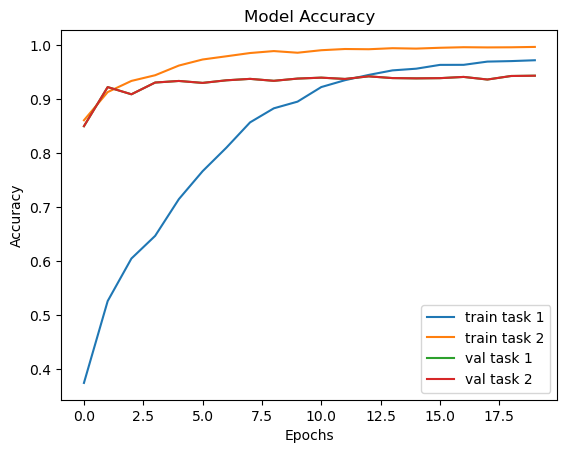

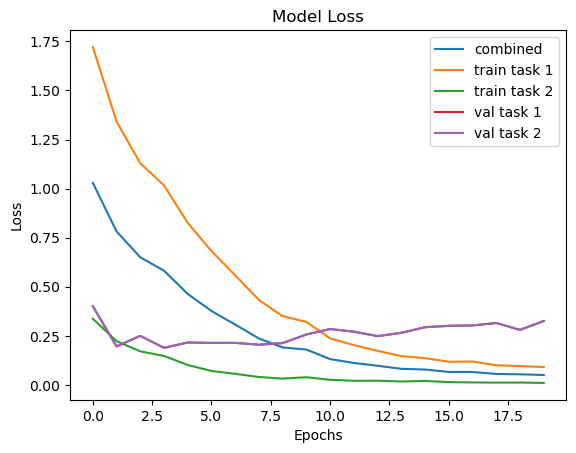

In [31]:
# accuracy plot
plt.plot(history.history['task_1_output_accuracy'])
plt.plot(history.history['task_2_output_accuracy'])
plt.plot(history.history['val_task_2_output_accuracy'])
plt.plot(history.history['val_task_2_output_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train task 1', 'train task 2', 'val task 1', 'val task 2'])
plt.show()

# loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['task_1_output_loss'])
plt.plot(history.history['task_2_output_loss'])
plt.plot(history.history['val_task_2_output_loss'])
plt.plot(history.history['val_task_2_output_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['combined' ,'train task 1', 'train task 2', 'val task 1', 'val task 2'])
plt.show()

In [32]:
# test model results
evaluation_results  = model.evaluate(X_test, 
                        [y_test, y_test_super],
                       batch_size=batch_size,
                       verbose=0)

# train model results
print('Test loss:', evaluation_results[0])
print('Test task 1 loss:', evaluation_results[1])
print('Test task 2 loss:', evaluation_results[2])
print('Test task 1 acc:', evaluation_results[3])
print('Test task 2 acc:', evaluation_results[4])

Test loss: 1.0968410968780518
Test task 1 loss: 1.859824776649475
Test task 2 loss: 0.33385732769966125
Test task 1 acc: 0.6718000173568726
Test task 2 acc: 0.9401999711990356


## 3.2. Case 2  - Batch Size = 256, Gamma=0.4, Adam Optimizer

Epoch 1/20
167/167 [==============================] - 92s 378ms/step - loss: 0.8937 - task_1_output_loss: 1.7306 - task_2_output_loss: 0.3358 - task_1_output_accuracy: 0.3716 - task_2_output_accuracy: 0.8618 - val_loss: 0.7102 - val_task_1_output_loss: 1.4122 - val_task_2_output_loss: 0.2422 - val_task_1_output_accuracy: 0.4935 - val_task_2_output_accuracy: 0.9025
Epoch 2/20
167/167 [==============================] - 61s 368ms/step - loss: 0.6872 - task_1_output_loss: 1.3811 - task_2_output_loss: 0.2246 - task_1_output_accuracy: 0.5096 - task_2_output_accuracy: 0.9128 - val_loss: 0.6249 - val_task_1_output_loss: 1.2353 - val_task_2_output_loss: 0.2181 - val_task_1_output_accuracy: 0.5601 - val_task_2_output_accuracy: 0.9133
Epoch 3/20
167/167 [==============================] - 63s 378ms/step - loss: 0.5620 - task_1_output_loss: 1.1516 - task_2_output_loss: 0.1689 - task_1_output_accuracy: 0.5947 - task_2_output_accuracy: 0.9355 - val_loss: 0.5729 - val_task_1_output_loss: 1.1735 - val_

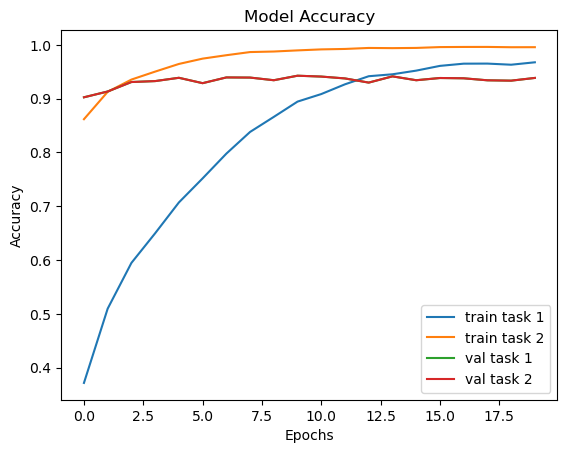

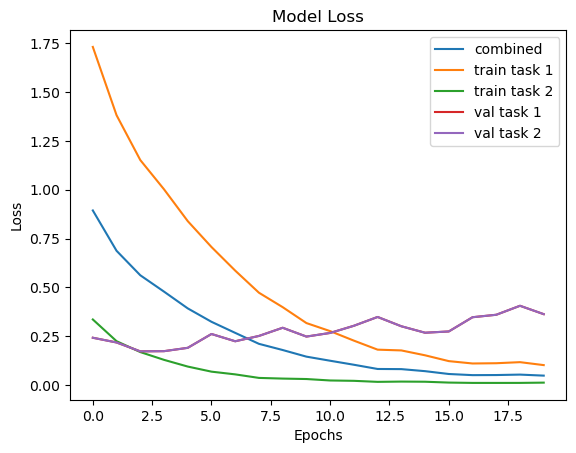

Test loss: 0.8686716556549072
Test task 1 loss: 1.682499647140503
Test task 2 loss: 0.3261198103427887
Test task 1 acc: 0.6697999835014343
Test task 2 acc: 0.9434999823570251


In [33]:
# training settings
batch_size = 256          # number of images per batch

# create a model
model = create_model(mlp_dropout=mlp_dropout)

# set gamma
gamma = 0.4

# compile model
model.compile(loss={'task_1_output': 'categorical_crossentropy',
                    'task_2_output': 'binary_crossentropy'},
              loss_weights={'task_1_output': gamma,
                            'task_2_output': 1-gamma},
              optimizer='adam',
              metrics=['accuracy'])

# set up call backs (pickle the best model only!)
callbacks = [
  keras.callbacks.ModelCheckpoint(
    filepath="/kaggle/working/base_model.keras",
    save_best_only=True,
    monitor="val_loss"
  )
]

# train and save in history for plotting
history = model.fit(
    {'input': X_train},
    {'task_1_output': y_train, 'task_2_output': y_train_super},
    batch_size=batch_size,
    epochs=num_epochs,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1,
)

# train model results
print('Train loss:', history.history['loss'][-1])
print('Train task 1 loss:', history.history['task_1_output_loss'][-1])
print('Train task 2 loss:', history.history['task_2_output_loss'][-1])
print('Train task 1 acc:', history.history['task_1_output_accuracy'][-1])
print('Train task 2 acc:', history.history['task_2_output_accuracy'][-1])

# accuracy plot
plt.plot(history.history['task_1_output_accuracy'])
plt.plot(history.history['task_2_output_accuracy'])
plt.plot(history.history['val_task_2_output_accuracy'])
plt.plot(history.history['val_task_2_output_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train task 1', 'train task 2', 'val task 1', 'val task 2'])
plt.show()

# loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['task_1_output_loss'])
plt.plot(history.history['task_2_output_loss'])
plt.plot(history.history['val_task_2_output_loss'])
plt.plot(history.history['val_task_2_output_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['combined' ,'train task 1', 'train task 2', 'val task 1', 'val task 2'])
plt.show()

# test model results
evaluation_results  = model.evaluate(X_test, 
                        [y_test, y_test_super],
                       batch_size=batch_size,
                       verbose=0)

# train model results
print('Test loss:', evaluation_results[0])
print('Test task 1 loss:', evaluation_results[1])
print('Test task 2 loss:', evaluation_results[2])
print('Test task 1 acc:', evaluation_results[3])
print('Test task 2 acc:', evaluation_results[4])

## 3.3. Case 3  - Batch Size = 256, Gamma=0.6, Adam Optimizer

Epoch 1/20
167/167 [==============================] - 93s 378ms/step - loss: 1.1704 - task_1_output_loss: 1.7240 - task_2_output_loss: 0.3398 - task_1_output_accuracy: 0.3750 - task_2_output_accuracy: 0.8580 - val_loss: 0.9682 - val_task_1_output_loss: 1.4363 - val_task_2_output_loss: 0.2661 - val_task_1_output_accuracy: 0.4873 - val_task_2_output_accuracy: 0.8900
Epoch 2/20
167/167 [==============================] - 61s 368ms/step - loss: 0.8843 - task_1_output_loss: 1.3282 - task_2_output_loss: 0.2184 - task_1_output_accuracy: 0.5316 - task_2_output_accuracy: 0.9121 - val_loss: 0.8647 - val_task_1_output_loss: 1.2998 - val_task_2_output_loss: 0.2120 - val_task_1_output_accuracy: 0.5488 - val_task_2_output_accuracy: 0.9157
Epoch 3/20
167/167 [==============================] - 63s 379ms/step - loss: 0.7479 - task_1_output_loss: 1.1309 - task_2_output_loss: 0.1733 - task_1_output_accuracy: 0.6065 - task_2_output_accuracy: 0.9336 - val_loss: 0.8578 - val_task_1_output_loss: 1.2642 - val_

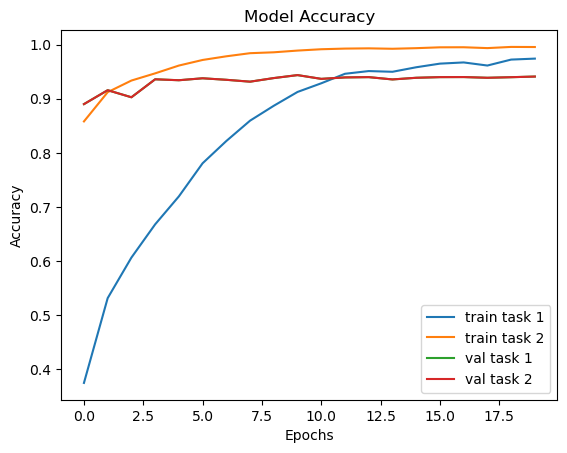

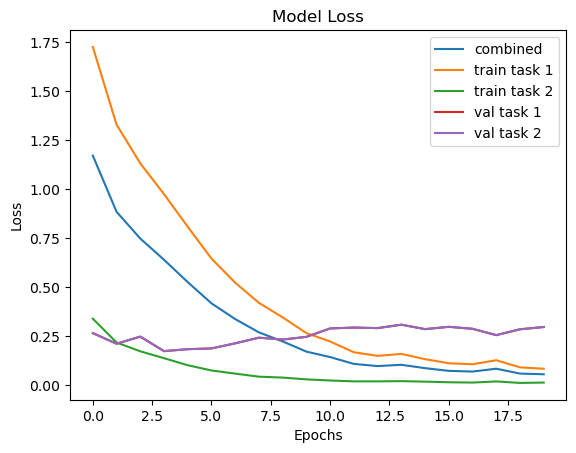

Test loss: 1.1399550437927246
Test task 1 loss: 1.69630765914917
Test task 2 loss: 0.3054260313510895
Test task 1 acc: 0.6669999957084656
Test task 2 acc: 0.9387999773025513


In [34]:
# training settings
batch_size = 256          # number of images per batch

# create a model
model = create_model(mlp_dropout=mlp_dropout)

# set gamma
gamma = 0.6

# compile model
model.compile(loss={'task_1_output': 'categorical_crossentropy',
                    'task_2_output': 'binary_crossentropy'},
              loss_weights={'task_1_output': gamma,
                            'task_2_output': 1-gamma},
              optimizer='adam',
              metrics=['accuracy'])

# set up call backs (pickle the best model only!)
callbacks = [
  keras.callbacks.ModelCheckpoint(
    filepath="/kaggle/working/base_model.keras",
    save_best_only=True,
    monitor="val_loss"
  )
]

# train and save in history for plotting
history = model.fit(
    {'input': X_train},
    {'task_1_output': y_train, 'task_2_output': y_train_super},
    batch_size=batch_size,
    epochs=num_epochs,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1,
)

# train model results
print('Train loss:', history.history['loss'][-1])
print('Train task 1 loss:', history.history['task_1_output_loss'][-1])
print('Train task 2 loss:', history.history['task_2_output_loss'][-1])
print('Train task 1 acc:', history.history['task_1_output_accuracy'][-1])
print('Train task 2 acc:', history.history['task_2_output_accuracy'][-1])

# accuracy plot
plt.plot(history.history['task_1_output_accuracy'])
plt.plot(history.history['task_2_output_accuracy'])
plt.plot(history.history['val_task_2_output_accuracy'])
plt.plot(history.history['val_task_2_output_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train task 1', 'train task 2', 'val task 1', 'val task 2'])
plt.show()

# loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['task_1_output_loss'])
plt.plot(history.history['task_2_output_loss'])
plt.plot(history.history['val_task_2_output_loss'])
plt.plot(history.history['val_task_2_output_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['combined' ,'train task 1', 'train task 2', 'val task 1', 'val task 2'])
plt.show()

# test model results
evaluation_results  = model.evaluate(X_test, 
                        [y_test, y_test_super],
                       batch_size=batch_size,
                       verbose=0)

# train model results
print('Test loss:', evaluation_results[0])
print('Test task 1 loss:', evaluation_results[1])
print('Test task 2 loss:', evaluation_results[2])
print('Test task 1 acc:', evaluation_results[3])
print('Test task 2 acc:', evaluation_results[4])

## 3.4. Case 4  - Batch Size = 128, Gamma=0.5, Adam Optimizer

Epoch 1/20
333/333 [==============================] - 95s 202ms/step - loss: 1.0271 - task_1_output_loss: 1.7220 - task_2_output_loss: 0.3322 - task_1_output_accuracy: 0.3783 - task_2_output_accuracy: 0.8655 - val_loss: 0.7976 - val_task_1_output_loss: 1.3753 - val_task_2_output_loss: 0.2199 - val_task_1_output_accuracy: 0.5049 - val_task_2_output_accuracy: 0.9137
Epoch 2/20
333/333 [==============================] - 67s 202ms/step - loss: 0.7694 - task_1_output_loss: 1.3303 - task_2_output_loss: 0.2084 - task_1_output_accuracy: 0.5288 - task_2_output_accuracy: 0.9186 - val_loss: 0.7219 - val_task_1_output_loss: 1.2219 - val_task_2_output_loss: 0.2219 - val_task_1_output_accuracy: 0.5589 - val_task_2_output_accuracy: 0.9112
Epoch 3/20
333/333 [==============================] - 67s 202ms/step - loss: 0.6525 - task_1_output_loss: 1.1382 - task_2_output_loss: 0.1668 - task_1_output_accuracy: 0.6057 - task_2_output_accuracy: 0.9363 - val_loss: 0.6633 - val_task_1_output_loss: 1.1425 - val_

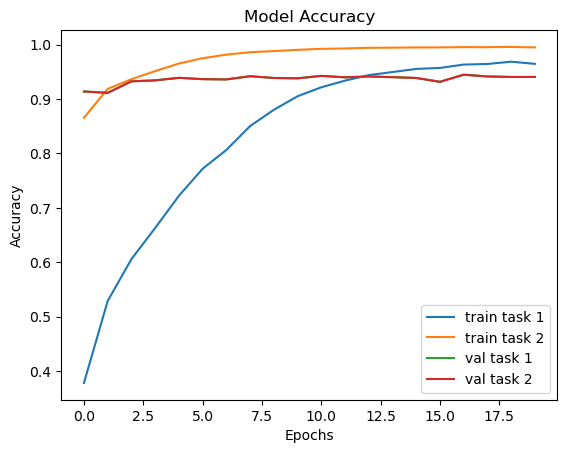

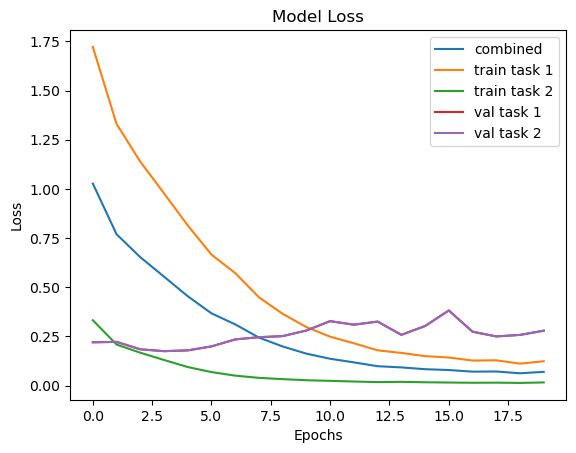

Test loss: 0.9469379186630249
Test task 1 loss: 1.6100170612335205
Test task 2 loss: 0.28385838866233826
Test task 1 acc: 0.6747000217437744
Test task 2 acc: 0.9373999834060669


In [35]:
# training settings
batch_size = 128          # number of images per batch

# create a model
model = create_model(mlp_dropout=mlp_dropout)

# set gamma
gamma = 0.5

# compile model
model.compile(loss={'task_1_output': 'categorical_crossentropy',
                    'task_2_output': 'binary_crossentropy'},
              loss_weights={'task_1_output': gamma,
                            'task_2_output': 1-gamma},
              optimizer='adam',
              metrics=['accuracy'])

# set up call backs (pickle the best model only!)
callbacks = [
  keras.callbacks.ModelCheckpoint(
    filepath="/kaggle/working/base_model.keras",
    save_best_only=True,
    monitor="val_loss"
  )
]

# train and save in history for plotting
history = model.fit(
    {'input': X_train},
    {'task_1_output': y_train, 'task_2_output': y_train_super},
    batch_size=batch_size,
    epochs=num_epochs,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1,
)

# train model results
print('Train loss:', history.history['loss'][-1])
print('Train task 1 loss:', history.history['task_1_output_loss'][-1])
print('Train task 2 loss:', history.history['task_2_output_loss'][-1])
print('Train task 1 acc:', history.history['task_1_output_accuracy'][-1])
print('Train task 2 acc:', history.history['task_2_output_accuracy'][-1])

# accuracy plot
plt.plot(history.history['task_1_output_accuracy'])
plt.plot(history.history['task_2_output_accuracy'])
plt.plot(history.history['val_task_2_output_accuracy'])
plt.plot(history.history['val_task_2_output_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train task 1', 'train task 2', 'val task 1', 'val task 2'])
plt.show()

# loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['task_1_output_loss'])
plt.plot(history.history['task_2_output_loss'])
plt.plot(history.history['val_task_2_output_loss'])
plt.plot(history.history['val_task_2_output_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['combined' ,'train task 1', 'train task 2', 'val task 1', 'val task 2'])
plt.show()

# test model results
evaluation_results  = model.evaluate(X_test, 
                        [y_test, y_test_super],
                       batch_size=batch_size,
                       verbose=0)

# train model results
print('Test loss:', evaluation_results[0])
print('Test task 1 loss:', evaluation_results[1])
print('Test task 2 loss:', evaluation_results[2])
print('Test task 1 acc:', evaluation_results[3])
print('Test task 2 acc:', evaluation_results[4])

## 3.5. Case 5  - Batch Size = 128, Gamma=0.5, SGD Optimizer

Epoch 1/20
333/333 [==============================] - 85s 204ms/step - loss: 1.3370 - task_1_output_loss: 2.1596 - task_2_output_loss: 0.5144 - task_1_output_accuracy: 0.1983 - task_2_output_accuracy: 0.7624 - val_loss: 1.1710 - val_task_1_output_loss: 1.9097 - val_task_2_output_loss: 0.4324 - val_task_1_output_accuracy: 0.3144 - val_task_2_output_accuracy: 0.8096
Epoch 2/20
333/333 [==============================] - 65s 195ms/step - loss: 1.1872 - task_1_output_loss: 1.9451 - task_2_output_loss: 0.4293 - task_1_output_accuracy: 0.2837 - task_2_output_accuracy: 0.8132 - val_loss: 1.1091 - val_task_1_output_loss: 1.8011 - val_task_2_output_loss: 0.4170 - val_task_1_output_accuracy: 0.3408 - val_task_2_output_accuracy: 0.8249
Epoch 3/20
333/333 [==============================] - 66s 199ms/step - loss: 1.1174 - task_1_output_loss: 1.8394 - task_2_output_loss: 0.3953 - task_1_output_accuracy: 0.3301 - task_2_output_accuracy: 0.8326 - val_loss: 1.0567 - val_task_1_output_loss: 1.7373 - val_

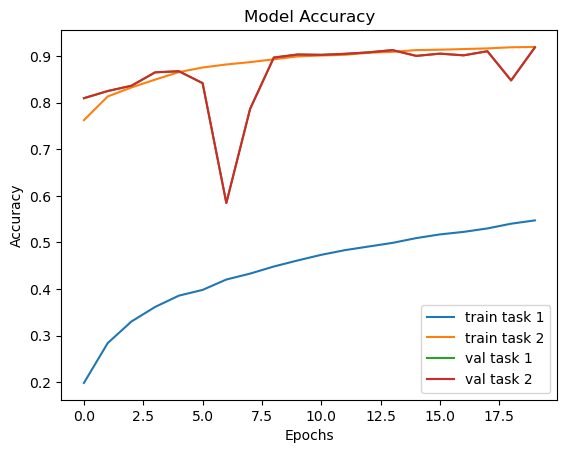

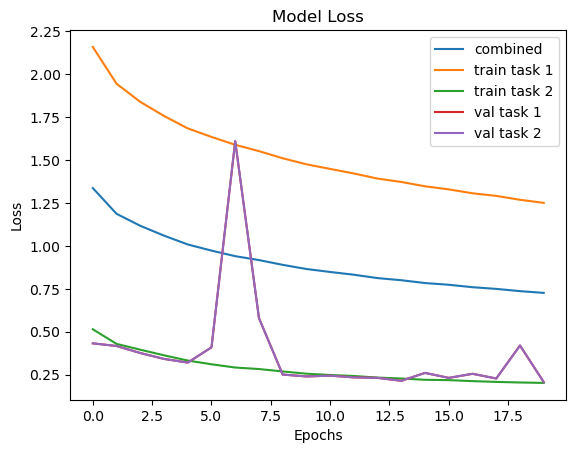

Test loss: 0.7279106974601746
Test task 1 loss: 1.2513192892074585
Test task 2 loss: 0.2045019119977951
Test task 1 acc: 0.5525000095367432
Test task 2 acc: 0.9207000136375427


In [36]:
# training settings
batch_size = 128          # number of images per batch

# create a model
model = create_model(mlp_dropout=mlp_dropout)

# set gamma
gamma = 0.5

# compile model
model.compile(loss={'task_1_output': 'categorical_crossentropy',
                    'task_2_output': 'binary_crossentropy'},
              loss_weights={'task_1_output': gamma,
                            'task_2_output': 1-gamma},
              optimizer='sgd',
              metrics=['accuracy'])

# set up call backs (pickle the best model only!)
callbacks = [
  keras.callbacks.ModelCheckpoint(
    filepath="/kaggle/working/base_model.keras",
    save_best_only=True,
    monitor="val_loss"
  )
]

# train and save in history for plotting
history = model.fit(
    {'input': X_train},
    {'task_1_output': y_train, 'task_2_output': y_train_super},
    batch_size=batch_size,
    epochs=num_epochs,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1,
)

# train model results
print('Train loss:', history.history['loss'][-1])
print('Train task 1 loss:', history.history['task_1_output_loss'][-1])
print('Train task 2 loss:', history.history['task_2_output_loss'][-1])
print('Train task 1 acc:', history.history['task_1_output_accuracy'][-1])
print('Train task 2 acc:', history.history['task_2_output_accuracy'][-1])

# accuracy plot
plt.plot(history.history['task_1_output_accuracy'])
plt.plot(history.history['task_2_output_accuracy'])
plt.plot(history.history['val_task_2_output_accuracy'])
plt.plot(history.history['val_task_2_output_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train task 1', 'train task 2', 'val task 1', 'val task 2'])
plt.show()

# loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['task_1_output_loss'])
plt.plot(history.history['task_2_output_loss'])
plt.plot(history.history['val_task_2_output_loss'])
plt.plot(history.history['val_task_2_output_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['combined' ,'train task 1', 'train task 2', 'val task 1', 'val task 2'])
plt.show()

# test model results
evaluation_results  = model.evaluate(X_test, 
                        [y_test, y_test_super],
                       batch_size=batch_size,
                       verbose=0)

# train model results
print('Test loss:', evaluation_results[0])
print('Test task 1 loss:', evaluation_results[1])
print('Test task 2 loss:', evaluation_results[2])
print('Test task 1 acc:', evaluation_results[3])
print('Test task 2 acc:', evaluation_results[4])